> **Für die Schieberegler in Abschnitt 6:** Im Menü `Run` auf `Run All Cells` klicken.

# Physikalisches Modell

Die Lichtquelle liegt bei $z=0$, die Öffnung bei $z=a$ und der Schirm bei $z=L$. Ein Lichtquellenpunkt ist $S_i=(x_i,y_i,0)$, ein Schirmpunkt $P=(X,Y,L)$.

Der gerade Strahl von $S_i$ nach $P$ schneidet die Öffnungsebene bei

$$x_a=x_i+\frac{a}{L}(X-x_i), \qquad y_a=y_i+\frac{a}{L}(Y-y_i).$$

Für eine zentrierte Raute mit halber Diagonale $r$ wird der Strahl genau dann durchgelassen, wenn

$$|x_a|+|y_a|\leq r.$$

Mit $N$ gleich gewichteten Lichtquellenpunkten ist die relative Helligkeit

$$I(X,Y)=\frac{1}{N}\sum_{i=1}^{N}\mathbf{1}\!\left(|x_a|+|y_a|\leq r\right).$$

Dabei ist $\mathbf{1}$ gleich 1 für einen durchgelassenen Strahl und sonst 0. Alle Lichtquellenpunkte tragen gleich stark zur Helligkeit bei. Beugung sowie entfernungs- und winkelabhängige Änderungen der Helligkeit werden nicht berücksichtigt.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.ndimage import gaussian_filter

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
})

## 1. Parameter

Alle Längen verwenden dieselbe frei wählbare Einheit.

In [2]:
# Physikalische Größen
# Abstände entlang der z-Achse
a = 13.0
L = 22.0

# Rechteckige Lichtquelle
source_width = 0.3
source_height = 8.5

# Rautenförmige Öffnung
aperture_half_diagonal = 3.0

# Raster für die Rechnung
target_source_points = 1200
# Berechneter Schirmausschnitt von -screen_half_size bis +screen_half_size
screen_half_size = 8.0
screen_points_per_axis = 200

# Glättung vor den Ableitungen
# Standardabweichung des Gauß-Filters in Rasterzellen.
# 0 bedeutet: keine Glättung.
smoothing_sigma_cells = 1.2

assert 0 < a < L, "Es muss 0 < a < L gelten."
assert source_width > 0 and source_height > 0
assert aperture_half_diagonal > 0
assert screen_points_per_axis >= 3
assert smoothing_sigma_cells >= 0

## 2. Lichtquelle als Punktraster

Die rechteckige Lichtquelle wird durch ein regelmäßiges Punktraster dargestellt. Die angegebene Punktzahl ist ein Zielwert. Sie kann leicht abweichen, damit die Abstände in $x$- und $y$-Richtung ungefähr gleich groß sind.

In [3]:
def make_source_grid(width, height, target_count):
    """Erzeugt ein regelmäßiges Raster mit ungefähr target_count Punkten."""
    if width <= 0 or height <= 0 or target_count < 4:
        raise ValueError(
            "Breite und Höhe müssen positiv sein, die Zielpunktzahl mindestens 4."
        )

    # Das Zahlenverhältnis nx/ny entspricht ungefähr width/height.
    nx = max(2, round(np.sqrt(target_count * width / height)))
    ny = max(2, round(target_count / nx))

    source_x = np.linspace(-width / 2, width / 2, nx)
    source_y = np.linspace(-height / 2, height / 2, ny)
    source_X, source_Y = np.meshgrid(source_x, source_y, indexing="xy")
    source_points = np.column_stack((source_X.ravel(), source_Y.ravel()))
    return source_x, source_y, source_points


source_x, source_y, source_points = make_source_grid(
    source_width, source_height, target_source_points
)
source_dx = source_x[1] - source_x[0]
source_dy = source_y[1] - source_y[0]

print(
    f"Quellraster: {len(source_x)} × {len(source_y)} = {len(source_points)} Punkte, "
    f"dx = {source_dx:.3f}, dy = {source_dy:.3f}"
)

Quellraster: 7 × 171 = 1197 Punkte, dx = 0.050, dy = 0.050


## 3. Relative Helligkeit

Für jeden Schirmpunkt wird geprüft, welche Strahlen von den Lichtquellenpunkten durch die Öffnung gelangen. Der Anteil dieser Strahlen ergibt $I(X,Y)$.

In [4]:
def inside_diamond(x, y, half_diagonal):
    """Prüft, welche Punkte innerhalb oder auf dem Rand der Raute liegen."""
    return np.abs(x) + np.abs(y) <= half_diagonal


def compute_intensity_map(
    source_points, a, L, aperture_half_diagonal,
    screen_half_size, screen_points_per_axis
):
    """Berechnet die relative Helligkeit auf einem quadratischen Schirm."""
    if not 0 < a < L:
        raise ValueError("Es muss 0 < a < L gelten.")

    x = np.linspace(-screen_half_size, screen_half_size, screen_points_per_axis)
    y = np.linspace(-screen_half_size, screen_half_size, screen_points_per_axis)
    X, Y = np.meshgrid(x, y, indexing="xy")
    # X und Y haben die Form (Anzahl y-Werte, Anzahl x-Werte).
    # Achse 0 entspricht y, Achse 1 entspricht x.

    passed_ray_count = np.zeros_like(X, dtype=np.int32)
    aperture_fraction = a / L

    for x_source, y_source in source_points:
        x_at_aperture = x_source + aperture_fraction * (X - x_source)
        y_at_aperture = y_source + aperture_fraction * (Y - y_source)
        ray_passes_aperture = inside_diamond(
            x_at_aperture, y_at_aperture, aperture_half_diagonal
        )
        passed_ray_count += ray_passes_aperture  # True wird als 1 gezählt.

    intensity = passed_ray_count / len(source_points)
    return x, y, intensity


In [5]:
x, y, I = compute_intensity_map(
    source_points=source_points,
    a=a,
    L=L,
    aperture_half_diagonal=aperture_half_diagonal,
    screen_half_size=screen_half_size,
    screen_points_per_axis=screen_points_per_axis,
)

assert I.shape == (len(y), len(x))
assert np.all((0 <= I) & (I <= 1))
print(f"I: Form {I.shape}, Minimum {I.min():.3f}, Maximum {I.max():.3f}")

I: Form (200, 200), Minimum 0.000, Maximum 1.000


## 4. Glättung und räumliche Ableitungen

Die Strahlenrechnung liefert die Intensität $I(X,Y)$. Vor den räumlichen Ableitungen wird $I$ geglättet, weil Ableitungen kleine Stufen im berechneten Raster verstärken.

Mit dem Gauß-Filter $G_\sigma$ ergibt sich

$$I_\sigma=G_\sigma * I.$$

`smoothing_sigma_cells` gibt die Standardabweichung des Gauß-Filters in Rasterzellen an. Ein größerer Wert glättet stärker und macht Übergänge breiter. Bei `smoothing_sigma_cells = 0` wird nicht geglättet. Dann gilt $I_\sigma=I$.

Der Gradientenbetrag ist definiert als

$$|\nabla I_\sigma|=\sqrt{\left(\frac{\partial I_\sigma}{\partial X}\right)^2+\left(\frac{\partial I_\sigma}{\partial Y}\right)^2}$$

Der Laplace-Operator ist

$$\nabla^2 I_\sigma=\frac{\partial^2 I_\sigma}{\partial X^2}+\frac{\partial^2 I_\sigma}{\partial Y^2}.$$

Sein Betrag $|\nabla^2 I_\sigma|$ entfernt das Vorzeichen.

In [6]:
# mode="nearest": Außerhalb des Rasters gilt jeweils der nächste Randwert.
I_for_derivatives = gaussian_filter(
    I, sigma=smoothing_sigma_cells, mode="nearest"
)

# Mit x und y verwendet np.gradient die tatsächlichen Rasterabstände.
dI_dy = np.gradient(I_for_derivatives, y, axis=0)
dI_dx = np.gradient(I_for_derivatives, x, axis=1)
gradient_magnitude = np.hypot(dI_dx, dI_dy)

d2I_dx2 = np.gradient(dI_dx, x, axis=1)
d2I_dy2 = np.gradient(dI_dy, y, axis=0)
laplacian = d2I_dx2 + d2I_dy2
absolute_laplacian = np.abs(laplacian)

print(f"Gradient: Maximum {gradient_magnitude.max():.3f}")
print(f"Laplace-Betrag: Maximum {absolute_laplacian.max():.3f}")

Gradient: Maximum 0.339
Laplace-Betrag: Maximum 1.543


## 5. Ergebnisse

Gradient und Laplace-Operator werden aus der geglätteten Intensität $I_\sigma$ berechnet. In der Laplace-Karte kennzeichnet Blau negative Werte, Weiß null und Rot positive Werte. Der Laplace-Betrag zeigt nur deren Stärke. Nur $I$ ist auf den Bereich von 0 bis 1 normiert. Die Werte der Ableitungen hängen auch von Rasterauflösung, Glättung und gewählter Längeneinheit ab.

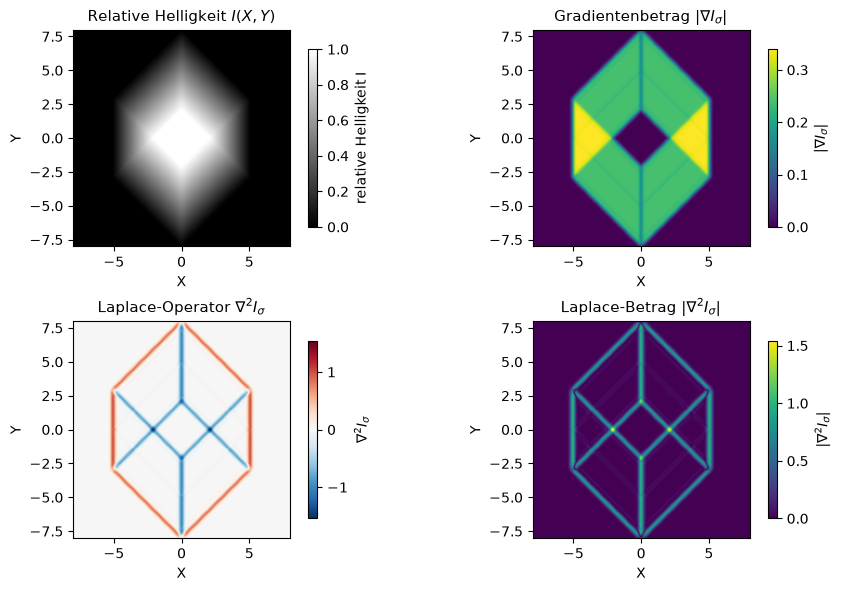

In [7]:
extent = [x.min(), x.max(), y.min(), y.max()]

fig, axes = plt.subplots(
    2, 2, figsize=(9.2, 5.8), dpi=100, constrained_layout=True
)
axes = axes.ravel()
laplacian_limit = absolute_laplacian.max()

images = [
    axes[0].imshow(I, origin="lower", extent=extent, cmap="gray", vmin=0, vmax=1),
    axes[1].imshow(gradient_magnitude, origin="lower", extent=extent, cmap="viridis", vmin=0),
    axes[2].imshow(
        laplacian, origin="lower", extent=extent, cmap="RdBu_r",
        vmin=-laplacian_limit, vmax=laplacian_limit,
    ),
    axes[3].imshow(
        absolute_laplacian, origin="lower", extent=extent,
        cmap="viridis", vmin=0, vmax=laplacian_limit,
    ),
]

titles = [
    "Relative Helligkeit $I(X,Y)$",
    r"Gradientenbetrag $|\nabla I_\sigma|$",
    r"Laplace-Operator $\nabla^2 I_\sigma$",
    r"Laplace-Betrag $|\nabla^2 I_\sigma|$",
]
colorbar_labels = [
    "relative Helligkeit I", r"$|\nabla I_\sigma|$",
    r"$\nabla^2 I_\sigma$", r"$|\nabla^2 I_\sigma|$",
]

for ax, image, title, label in zip(axes, images, titles, colorbar_labels):
    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_aspect("equal")
    fig.colorbar(image, ax=ax, label=label, shrink=0.82)

plt.show()

## 6. Helligkeitsprofile zum Vergleich mit Messungen

Die Profile werden direkt mit dem Strahlenmodell berechnet. Die Glättung aus Abschnitt 4 wird nicht verwendet.

In [8]:
import ipywidgets as widgets
from IPython.display import display


def compute_intensity_at_screen_points(
    source_points, screen_x, screen_y, a, L, aperture_half_diagonal
):
    """Berechnet I für eine Liste frei gewählter Schirmpunkte."""
    screen_x = np.asarray(screen_x, dtype=float)
    screen_y = np.asarray(screen_y, dtype=float)
    if screen_x.shape != screen_y.shape:
        raise ValueError("screen_x und screen_y müssen dieselbe Form haben.")

    passed_ray_count = np.zeros(screen_x.shape, dtype=np.int32)
    aperture_fraction = a / L

    for x_source, y_source in source_points:
        x_at_aperture = x_source + aperture_fraction * (screen_x - x_source)
        y_at_aperture = y_source + aperture_fraction * (screen_y - y_source)
        passed_ray_count += inside_diamond(
            x_at_aperture, y_at_aperture, aperture_half_diagonal
        )

    return passed_ray_count / len(source_points)


def compute_intensity_profile(
    profile_axis="X", fixed_coordinate=0.0, number_of_points=401
):
    """Berechnet ein X- oder Y-Profil der relativen Helligkeit."""
    if profile_axis not in ("X", "Y"):
        raise ValueError("profile_axis muss 'X' oder 'Y' sein.")
    if not -screen_half_size <= fixed_coordinate <= screen_half_size:
        raise ValueError("Die feste Koordinate muss auf dem Schirm liegen.")

    profile_coordinate = np.linspace(
        -screen_half_size, screen_half_size, number_of_points
    )
    if profile_axis == "X":
        screen_x = profile_coordinate
        screen_y = np.full_like(profile_coordinate, fixed_coordinate)
    else:
        screen_x = np.full_like(profile_coordinate, fixed_coordinate)
        screen_y = profile_coordinate

    intensity_profile = compute_intensity_at_screen_points(
        source_points=source_points,
        screen_x=screen_x,
        screen_y=screen_y,
        a=a,
        L=L,
        aperture_half_diagonal=aperture_half_diagonal,
    )
    return profile_coordinate, intensity_profile


false_color_map = LinearSegmentedColormap.from_list(
    "false_colors",
    ["#5bcbc2", "#f08fbf", "#f49a56", "#75d58b", "#83c3ff"],
)


def create_profile_figure(
    profile_axis="X", fixed_coordinate=0.0, display_mode="Falschfarben"
):
    """Erzeugt Helligkeitsbild und Helligkeitsprofil."""
    profile_coordinate, intensity_profile = compute_intensity_profile(
        profile_axis, fixed_coordinate
    )
    fixed_axis = "Y" if profile_axis == "X" else "X"
    if display_mode == "Falschfarben":
        color_map = false_color_map
    elif display_mode == "Graustufen":
        color_map = "gray"
    else:
        raise ValueError(
            "display_mode muss 'Falschfarben' oder 'Graustufen' sein."
        )

    fig, (ax_map, ax_profile) = plt.subplots(
        1, 2, figsize=(11.5, 4.6), constrained_layout=True,
        gridspec_kw={"width_ratios": [1, 1.15]},
    )

    image = ax_map.imshow(
        I, origin="lower",
        extent=[x.min(), x.max(), y.min(), y.max()],
        cmap=color_map, vmin=0, vmax=1, interpolation="nearest",
    )
    if profile_axis == "X":
        ax_map.axhline(
            fixed_coordinate, color="#555555", linewidth=0.9,
            linestyle=(0, (4, 3)), alpha=0.8,
        )
    else:
        ax_map.axvline(
            fixed_coordinate, color="#555555", linewidth=0.9,
            linestyle=(0, (4, 3)), alpha=0.8,
        )
    ax_map.set(
        title=f"Relative Helligkeit $I(X,Y)$ ({display_mode})",
        xlabel="X", ylabel="Y", aspect="equal",
        xlim=(-screen_half_size, screen_half_size),
        ylim=(-screen_half_size, screen_half_size),
    )
    fig.colorbar(
        image, ax=ax_map, label="$I(X,Y)$", ticks=[0, 1], shrink=0.86
    )

    ax_profile.plot(
        profile_coordinate, intensity_profile, color="#202020", linewidth=2.0
    )
    ax_profile.set(
        title=f"{profile_axis}-Profil bei {fixed_axis} = {fixed_coordinate:.1f}",
        xlabel=profile_axis, ylabel="relative Helligkeit I",
        xlim=(-screen_half_size, screen_half_size), ylim=(-0.02, 1.02),
    )
    ax_profile.grid(alpha=0.25)
    return fig

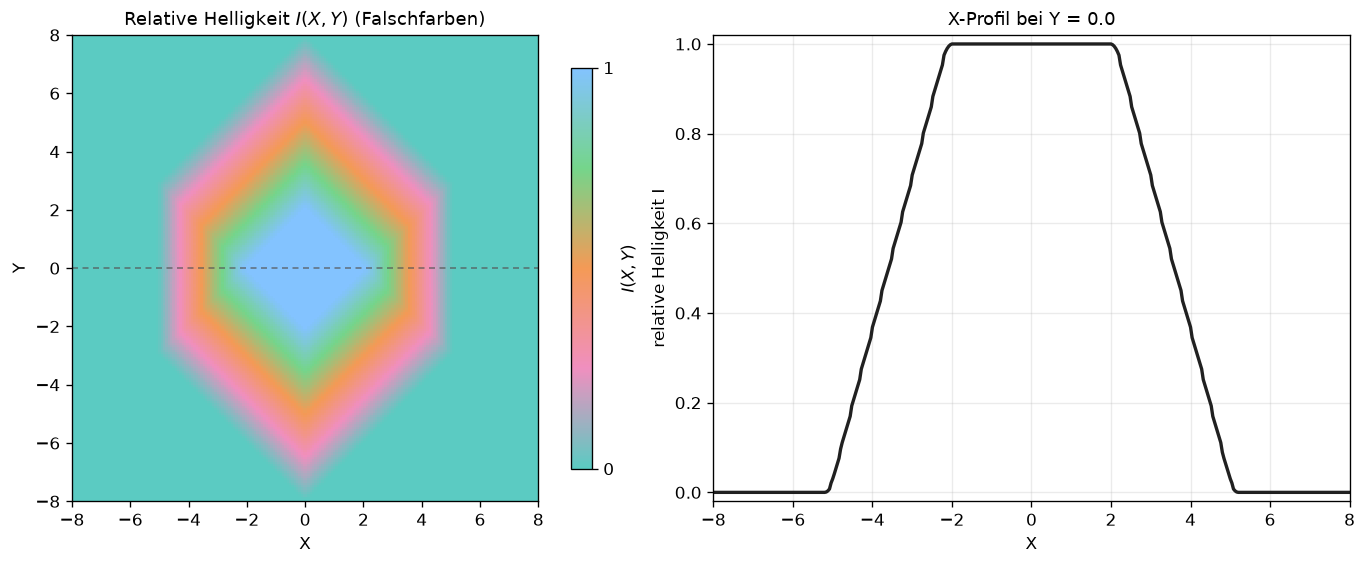

In [9]:
display_mode_selector = widgets.ToggleButtons(
    options=["Falschfarben", "Graustufen"],
    value="Falschfarben", description="Darstellung",
)
profile_axis_selector = widgets.ToggleButtons(
    options=[("X-Profil", "X"), ("Y-Profil", "Y")],
    value="X", description="Profil",
)
fixed_coordinate_slider = widgets.FloatSlider(
    value=0.0, min=-screen_half_size, max=screen_half_size, step=0.1,
    description="Y fest", continuous_update=False, readout_format=".1f",
    layout=widgets.Layout(width="460px"),
    style={"description_width": "70px"},
)

display(widgets.VBox([
    display_mode_selector, profile_axis_selector, fixed_coordinate_slider
]))
profile_figure = create_profile_figure(
    "X", 0.0, display_mode="Falschfarben"
)
profile_display = display(profile_figure, display_id=True)
plt.close(profile_figure)


def update_profile(change=None):
    """Ersetzt die Grafik mit den gewählten Einstellungen."""
    profile_axis = profile_axis_selector.value
    fixed_coordinate_slider.description = (
        "Y fest" if profile_axis == "X" else "X fest"
    )
    figure = create_profile_figure(
        profile_axis, fixed_coordinate_slider.value,
        display_mode=display_mode_selector.value,
    )
    profile_display.update(figure)
    plt.close(figure)


display_mode_selector.observe(update_profile, names="value")
profile_axis_selector.observe(update_profile, names="value")
fixed_coordinate_slider.observe(update_profile, names="value")